In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error


### 1. Loading data

In [2]:
df = pd.read_csv('../data/data.csv')
print(df.shape)
df.info()

(4600, 18)
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float

### 2. data Cleaning

In [3]:
# drop non-useful columns
df_cleaned = df.drop(['date', 'street', 'country'], axis=1)

# remove data errors: houses with price = 0
zero_count = (df_cleaned['price'] == 0).sum()
print(f"Rows with price = 0: {zero_count}")
df_cleaned = df_cleaned[df_cleaned['price'] != 0]
print(f"Shape after cleaning: {df_cleaned.shape}")

Rows with price = 0: 49
Shape after cleaning: (4551, 15)


### 3. Understanding the data - Visualising

Average house price: 557905.90
Price range: 7800 — 26590000


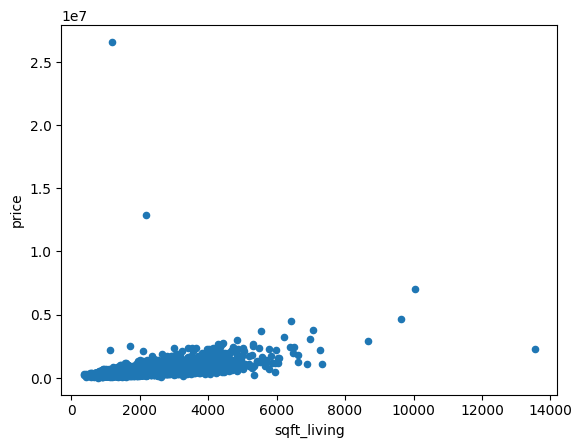

In [4]:
df_cleaned.plot(kind="scatter", x="sqft_living", y="price")

avg_price = df_cleaned["price"].mean()
print(f"Average house price: {avg_price:.2f}")
print(f"Price range: {df_cleaned['price'].min():.0f} — {df_cleaned['price'].max():.0f}")

### 4. Preparing Training and Testing Data

#### 4.1 Splitting data training/test

In [5]:
train_df = df_cleaned.sample(frac=0.8, random_state=42)
test_df = df_cleaned.drop(train_df.index)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")

Train: (3641, 15)
Test:  (910, 15)


#### 4.2 Remove outliers - extreme values

In [6]:
# IQR method for outlier removal (training data only)
Q1 = train_df['price'].quantile(0.25)
Q3 = train_df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 2.0 * IQR
upper_bound = Q3 + 2.0 * IQR

before = len(train_df)
train_df = train_df[(train_df["price"] >= lower_bound) & (train_df["price"] <= upper_bound)]

print(f"IQR: {IQR:.0f}, Bounds: [{max(0, lower_bound):.0f}, {upper_bound:.0f}]")
print(f"Removed {before - len(train_df)} outliers from training data ({len(train_df)} remaining)")

IQR: 330017, Bounds: [0, 1317033]
Removed 128 outliers from training data (3513 remaining)


#### 4.3 Target Encoding

In [7]:
# compute encoding maps from training data only
city_avg = train_df.groupby("city")["price"].mean()
statezip_avg = train_df.groupby("statezip")["price"].mean()
global_avg = train_df["price"].mean()

# apply to train
train_df["city_encoded"] = train_df["city"].map(city_avg)
train_df["statezip_encoded"] = train_df["statezip"].map(statezip_avg)

# apply to test (fillna handles unseen categories)
test_df["city_encoded"] = test_df["city"].map(city_avg).fillna(global_avg)
test_df["statezip_encoded"] = test_df["statezip"].map(statezip_avg).fillna(global_avg)

# drop original string columns
train_df = train_df.drop(["city", "statezip"], axis=1)
test_df = test_df.drop(["city", "statezip"], axis=1)

print(f"Columns: {train_df.columns.tolist()}")

Columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city_encoded', 'statezip_encoded']


#### 4.4 Feature / Target Separation

In [8]:
X_train = train_df.drop("price", axis=1)
y_train = train_df["price"]

X_test = test_df.drop("price", axis=1)
y_test = test_df["price"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (3513, 14), y_train: (3513,)
X_test:  (910, 14), y_test:  (910,)


### 5. Normalisation  - Feature Scaling

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f"Peak to peak (raw):\n{np.ptp(X_train, axis=0)}\n")
print(f"Peak to peak (scaled):\n{np.ptp(X_train_scaled, axis=0)}")

Peak to peak (raw):
bedrooms            8.000000e+00
bathrooms           5.750000e+00
sqft_living         6.260000e+03
sqft_lot            1.073580e+06
floors              2.500000e+00
waterfront          1.000000e+00
view                4.000000e+00
condition           4.000000e+00
sqft_above          4.820000e+03
sqft_basement       2.330000e+03
yr_built            1.140000e+02
yr_renovated        2.014000e+03
city_encoded        9.110453e+05
statezip_encoded    6.890438e+05
dtype: float64

Peak to peak (scaled):
[ 9.0081254   7.92884615  7.54745941 29.02346513  4.65503149 14.85150078
  5.8635685   5.97158238  6.23327095  5.42203843  3.86096156  2.05239506
  6.73569483  4.26639013]


### 6. Model Training

In [10]:
model = SGDRegressor(max_iter=10000, random_state=42)
model.fit(X_train_scaled, y_train)
print(f"Iterations: {model.n_iter_}, Weight updates: {model.t_}")

Iterations: 17, Weight updates: 59722.0


In [11]:
print(f"Weights:\n{dict(zip(X_train.columns, model.coef_))}\n")
print(f"Bias: {model.intercept_[0]:.2f}")

Weights:
{'bedrooms': np.float64(-9148.60553261405), 'bathrooms': np.float64(22968.653405564997), 'sqft_living': np.float64(60333.75695097343), 'sqft_lot': np.float64(-2341.9324008271033), 'floors': np.float64(13020.219626035001), 'waterfront': np.float64(10274.017620504734), 'view': np.float64(25650.194785621767), 'condition': np.float64(11042.384725108079), 'sqft_above': np.float64(54771.661755735324), 'sqft_basement': np.float64(17891.89878363067), 'yr_built': np.float64(-30464.982417061838), 'yr_renovated': np.float64(-11.617925597891398), 'city_encoded': np.float64(17044.09664954959), 'statezip_encoded': np.float64(112723.68782312068)}

Bias: 497938.21


### 7. Evaluation

In [12]:
# use scaler fitted on training data (never fit_transform on test)
X_test_scaled = scaler.transform(X_test)
predictions = model.predict(X_test_scaled)
predictions_training = model.predict(X_train_scaled)

In [13]:
np.set_printoptions(precision=2)
print(f"Predicted: {predictions[:10]}")
print(f"Actual:    {y_test[:10].values}")

Predicted: [560175.07 554742.74 397864.7  505731.54 556297.28 761361.59 553768.11
 559294.98 441795.62 232150.64]
Actual:    [420000. 550000. 490000. 640000. 419000. 698000. 400000. 403000. 335000.
 308500.]


In [14]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Average house price: {avg_price:.2f}")
print(f"Test data RMSE: {rmse:.2f}")
print(f"Test data RMSE as % of avg price: {rmse/avg_price*100:.1f}%")


rmse_training = np.sqrt(mean_squared_error(y_train, predictions_training))
print(f"Train data RMSE: {rmse_training:.2f}")
print(f"Train data RMSE as % of avg price: {rmse_training/avg_price*100:.1f}%")

Average house price: 557905.90
Test data RMSE: 252041.80
Test data RMSE as % of avg price: 45.2%
Train data RMSE: 117761.49
Train data RMSE as % of avg price: 21.1%
